Инициализация среды

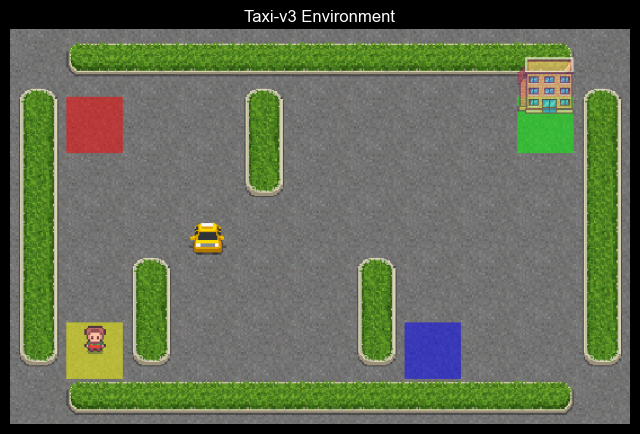

n_states=500, n_actions=6


In [54]:
import sys, os
import pygame
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()

img = env.render()
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Taxi-v3 Environment")
plt.show()

n_states = env.observation_space.n
n_actions = env.action_space.n
print("n_states=%i, n_actions=%i" % (n_states, n_actions))

Создание стохастической политики

In [55]:
def initialize_policy(n_states, n_actions):
    policy = np.ones((n_states, n_actions)) / n_actions
    return policy
policy = initialize_policy(n_states, n_actions)

assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

Игра с моделью

In [56]:
def generate_session(env, policy, t_max=10**4):
    """
     Играть до конца или t_max тиков.
    :param policy: массив вида [n_states, n_actions] с вероятностями действий
    :returns: список состояний, список действий и сумма наград
    """
    states, actions = [], []
    total_reward = 0.

    reset_result = env.reset()
    if isinstance(reset_result, tuple):
        s = reset_result[0]
    else:
        s = reset_result

    for t in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])
        step_result = env.step(a)
        if len(step_result) == 4:
            new_s, r, done, info = step_result
        else:
            new_s, r, terminated, truncated, info = step_result
            done = terminated or truncated
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        if done:
            break

    return states, actions, total_reward

s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

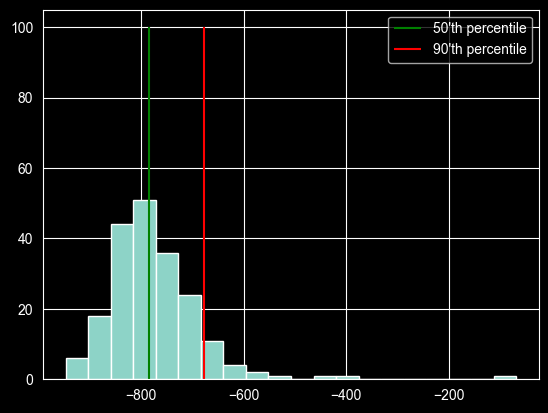

In [57]:
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]
plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()
plt.show()

Шаги кросс-энтропийного метода

In [58]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Выберите состояния и действия из игры, которые имеют награды >= процентиль
    :param states_batch: список списков состояний, states_batch[session_i][t]
    :param action_batch: список списков действий, action_batch[session_i][t]
    :param rewards_batch: список наград, rewards_batch[session_i]
    :returns: elite_states, elite_actions, одномерные списки состояний и соответствующих действий лучших сессий
    """
    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states = []
    elite_actions = []

    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


In [59]:
states_batch = [
    [1, 2, 3], # игра1
    [4, 2, 0, 2], # игра2
    [3, 1], # игра3
]
actions_batch = [
    [0, 2, 4], # игра1
    [3, 2, 0, 1], # игра2
    [3, 3], # игра3
]
rewards_batch = [
    3, # игра1
    4, # игра2
    5, # игра3
]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) \
and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]), \
"Для процентиля 0 вы должны вернуть все состояния и действия в хронологическом порядке."
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and \
np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3]), \
"Для процентиля 30 вы должны выбрать состояния/действия только из двух первых"
assert np.all(test_result_90[0] == [3, 1]) and \
np.all(test_result_90[1] == [3, 3]), \
"Для процентиля 90 вы должны выбирать состояния/действия только из одной игры."
assert np.all(test_result_100[0] == [3, 1]) and\
np.all(test_result_100[1] == [3, 3]), \
"Убедитесь, что вы используете >=, а не >. Также дважды проверьте, как вы вычисляете процентиль."

In [60]:
def get_new_policy(elite_states, elite_actions):
    """
    Учитывая список лучших состояний/действий от select_elites,
    возвращает новую политику, где вероятность каждого действия пропорциональна
    policy[s_i,a_i] ~ #[появления s_i и a_i в элитарных состояниях/действиях]
    Не забудьте нормализовать политику, чтобы получить действительные вероятности и обработать
    случай 0/0.
    Для состояний, в которых вы никогда не находились, используйте равномерное распределение
    (1/n_actions для всех состояний).
    :param elite_states: одномерный список состояний лучших сессий.
    :param elite_actions: одномерный список действий лучших сессий.
    """
    from collections import defaultdict
    new_policy = np.zeros([n_states, n_actions])

    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1

    for s in range(n_states):
        total = new_policy[s].sum()
        if total > 0:
            new_policy[s] = new_policy[s] / total
        else:
            new_policy[s] = 1.0 / n_actions

    return new_policy

Тренировочный цикл

mean reward = -152.860, threshold=1.500


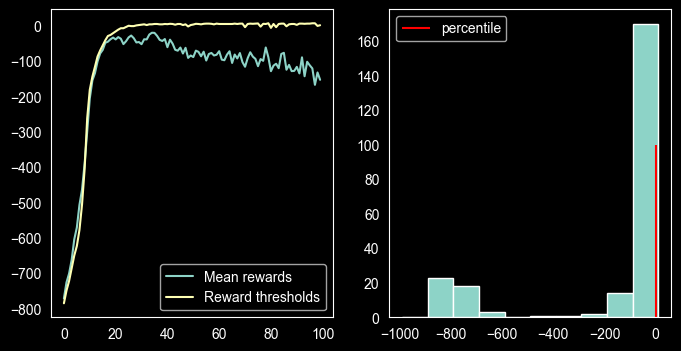

In [61]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Удобная функция, отображающая прогресс обучения
    """
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
    [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

# сбросить политику на всякий случай
policy = initialize_policy(n_states, n_actions)
#Эксперимент
n_sessions = 250 # число сессий

percentile = 50 # процент сессий с наивысшей наградой
learning_rate = 0.5 # насколько быстро обновляется политика, по шкале от 0 до 1
log = []
for i in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)  # выбор лучших
    new_policy = get_new_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    show_progress(rewards_batch, log, percentile)

Сходимость по задаче такси наступает примерно через 20 эпох, когда фиксируются почти максимальные показатели. При выходе на плато, когда большинство сессий завершается удачно, возникает трудность, связанная с фиксированным процентилем. В элиту отбираются сессии с наградой выше медианы, однако медиана в этой ситуации отражает усредненные по качеству траектории, а не наилучшие. В итоге политика обучения подстраивается под эти средние результаты, упуская из виду более перспективные варианты. Это приводит к падению средней награды до отметки -50/-100.